In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import pickle
import collision
import os
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights

In [113]:
species = "RbKRb"
path = f'{species}/pickle/'

rrkm_lifetimes = {"RbCs" : 2.1, "NaK" : 58, "NaRb" : 92, "RbKRb" : 1e5}

rrkm = rrkm_lifetimes[species]

mean = []
std = []
percentage = []
xs = np.round(np.pow(10, np.arange(-2, 2, 0.1)), 3)
above = []
within_10 = []
max_delay = []

for x in xs:
    with open(path + f'x_{x}.pkl', 'rb') as f:
        pkl_dict = pickle.load(f)
        percentage.append(pkl_dict['positive'])

        normalized = (pkl_dict['mean_spacing'] / 2 / np.pi) * np.array(pkl_dict["delay"])
        above.append((normalized > rrkm).sum() / len(pkl_dict["delay"]))
        within_10.append(((normalized > rrkm * 0.9) & (normalized < rrkm * 1.1)).sum() / len(pkl_dict["delay"]))

        log_10 = np.log10(normalized[normalized > 0])
        max_delay.append(np.max(normalized))
        mean.append(np.mean(log_10))
        std.append(np.std(log_10))

In [114]:
print(max_delay)

[np.float64(618.8863540322368), np.float64(521.312638449156), np.float64(705.1774002432409), np.float64(323.3218933228605), np.float64(583.5697730263148), np.float64(594.0393654375532), np.float64(459.018186506259), np.float64(451.3349656937368), np.float64(700.4514103214087), np.float64(323.937418186365), np.float64(545.8471586522176), np.float64(581.23772608804), np.float64(379.1383243542098), np.float64(543.4044599278271), np.float64(375.13157673118087), np.float64(406.1454031816071), np.float64(212.22640073710278), np.float64(678.3693626844896), np.float64(269.68585023036843), np.float64(342.45877458973825), np.float64(222.1123377054788), np.float64(229.4716527389958), np.float64(215.12329959913862), np.float64(153.15337834922073), np.float64(419.1288144385639), np.float64(193.5345716190577), np.float64(168.01986642766855), np.float64(263.5051784335855), np.float64(137.30436951892315), np.float64(261.67854097810863), np.float64(516.6662703710064), np.float64(127.36377601269199), np

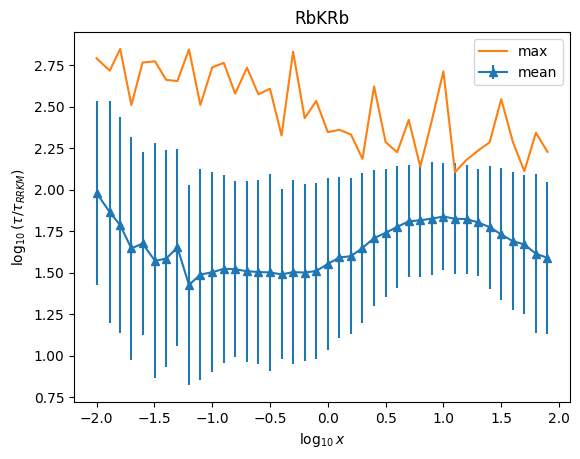

In [107]:
plt.errorbar(np.log10(xs), mean, std, marker='^', label="mean")
plt.plot(np.log10(xs), max_delay, label="max")
plt.xlabel(f"$\\log_{{10}} x$")
plt.ylabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
plt.title(species)
plt.legend()
plt.savefig(f"{species}/mean.pdf")

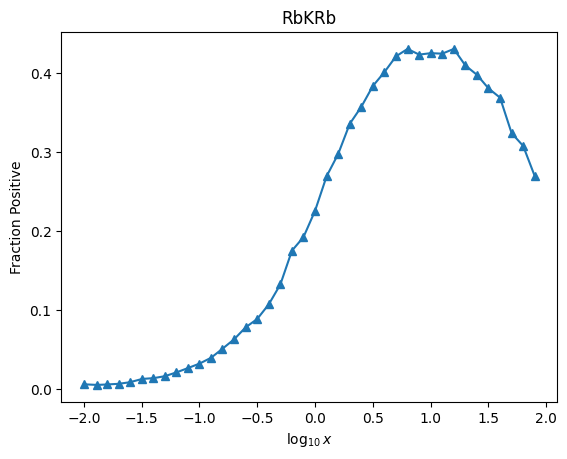

In [108]:
plt.plot(np.log10(xs), percentage, marker='^')
plt.xlabel(f"$\\log_{{10}} x$")
plt.ylabel(f"Fraction Positive")
plt.title(species)
plt.savefig(f"{species}/positive.pdf")

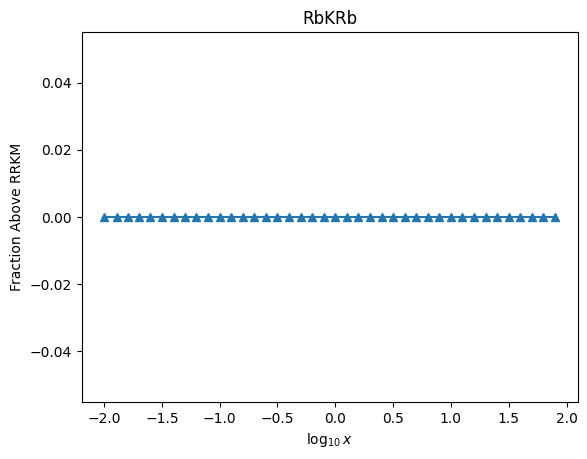

In [109]:
plt.plot(np.log10(xs), above, marker='^')
plt.xlabel(f"$\\log_{{10}} x$")
plt.ylabel(f"Fraction Above RRKM")
plt.title(species)
plt.savefig(f"{species}/above.pdf")

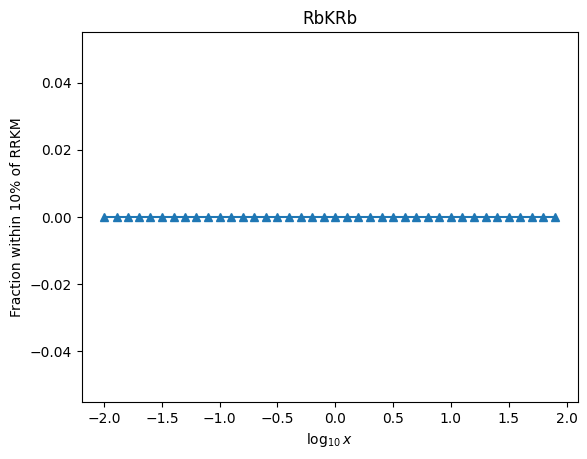

In [110]:
plt.plot(np.log10(xs), within_10, marker='^')
plt.xlabel(f"$\\log_{{10}} x$")
plt.ylabel(f"Fraction within 10% of RRKM")
plt.title(species)
plt.savefig(f"{species}/within.pdf")

450


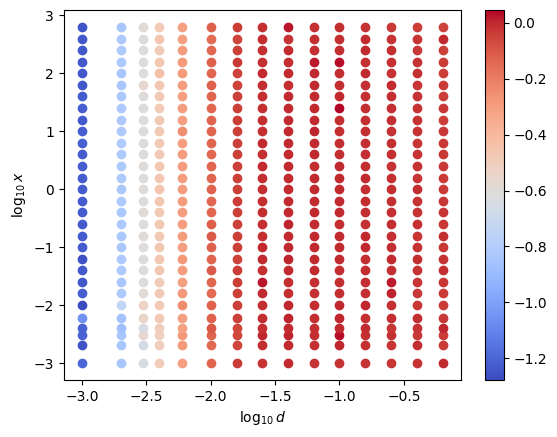

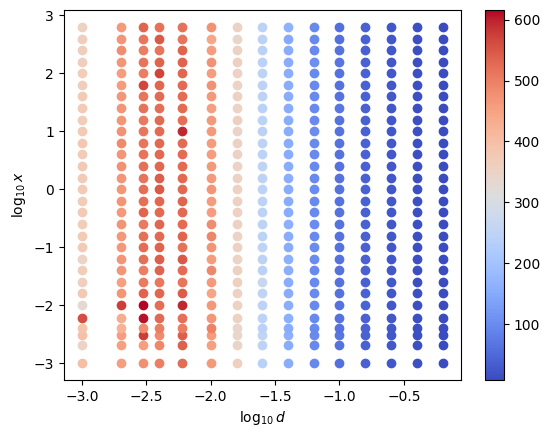

In [68]:
from matplotlib import colormaps, cm, colors

path = f'Sweep/data_fine_449.pkl'

with open(path, 'rb') as f:
    data = pickle.load(f)

print(len(data))

spacings = []
couplings = []
mean_delays = []
absolute_delays = []

for d in data:
    # if d["mean_spacing"] < 100:
    #     continue
        # print(d["mean_spacing"], d["mean_x"], d["mean"])
    spacings.append(np.log10(d["mean_spacing"]))
    couplings.append(np.log10(d["mean_x"]))
    mean_delays.append(np.log10(d["mean"]))
    absolute_delays.append(d["absolute_delay"])

#####################################################

fig, ax = plt.subplots()

cmap = colormaps.get_cmap('coolwarm')
# color = cmap(mean_delays)[..., :3]

norm = colors.Normalize(min(mean_delays), max(mean_delays))
fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)

for i in range(len(mean_delays)):
    plt.scatter(spacings[i], couplings[i], color=cmap(norm(mean_delays[i])))

plt.xlabel(r"$\log_{10} d$")
plt.ylabel(r"$\log_{10} x$")
plt.show()

#####################################################

fig, ax = plt.subplots()

cmap = colormaps.get_cmap('coolwarm')
# color = cmap(mean_delays)[..., :3]

norm = colors.Normalize(min(absolute_delays), max(absolute_delays))
fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)

for i in range(len(absolute_delays)):
    plt.scatter(spacings[i], couplings[i], color=cmap(norm(absolute_delays[i])))

plt.xlabel(r"$\log_{10} d$")
plt.ylabel(r"$\log_{10} x$")
plt.show()


In [44]:
norm(-5)

np.float64(0.04498854242624261)